In [92]:
import os
import glob
import pandas as pd
from tqdm import tqdm
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import GroupShuffleSplit

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR
from sklearn.metrics import roc_auc_score
import copy
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [8]:
DATA_DIR_A = '/kaggle/input/the-physionet-challenge-2019-dataset/training_setA/training_setA'
DATA_DIR_B = '/kaggle/input/the-physionet-challenge-2019-dataset/training_setB/training_setB'
pd.set_option('display.max_columns', None)

In [4]:
files_A = sorted(glob.glob(os.path.join(DATA_DIR_A, '*.psv')))
files_B = sorted(glob.glob(os.path.join(DATA_DIR_B, '*.psv')))
all_files = files_A + files_B

print(f"Found {len(files_A):,} files in Set A.")
print(f"Found {len(files_B):,} files in Set B.")
print(f"Total files to merge: {len(all_files):,}")

Found 20,336 files in Set A.
Found 20,000 files in Set B.
Total files to merge: 40,336


In [5]:
df_list = []
current_patient_id = 1

for filepath in tqdm(all_files):
    temp_df = pd.read_csv(filepath, sep='|')
    temp_df.insert(0, 'Patient_ID', current_patient_id)
    
    df_list.append(temp_df)
    
    current_patient_id += 1

100%|██████████| 40336/40336 [06:20<00:00, 105.93it/s]


In [6]:
master_df = pd.concat(df_list, ignore_index=True)

output_filename = 'physionet_combined.csv'
master_df.to_csv(output_filename, index=False)

print(f"Master CSV saved as:  {output_filename}")
print(f"Total Rows:           {master_df.shape[0]:,}")
print(f"Total Columns:        {master_df.shape[1]}")
print(f"Total Unique IDs:     {master_df['Patient_ID'].nunique():,}")

Master CSV saved as:  physionet_combined.csv
Total Rows:           1,552,210
Total Columns:        42
Total Unique IDs:     40,336


In [9]:

display(master_df.head())
display(master_df.tail())

,Patient_ID,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,FiO2,pH,PaCO2,SaO2,AST,BUN,Alkalinephos,Calcium,Chloride,Creatinine,Bilirubin_direct,Glucose,Lactate,Magnesium,Phosphate,Potassium,Bilirubin_total,TroponinI,Hct,Hgb,PTT,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel
0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,1,0
1,1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,2,0
2,1,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,3,0
3,1,90.0,95.0,NaN,NaN,NaN,NaN,30.0,NaN,24.0,NaN,NaN,7.36,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,4,0
4,1,103.0,88.5,NaN,122.0,91.33,NaN,24.5,NaN,NaN,NaN,0.28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,5,0


,Patient_ID,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,FiO2,pH,PaCO2,SaO2,AST,BUN,Alkalinephos,Calcium,Chloride,Creatinine,Bilirubin_direct,Glucose,Lactate,Magnesium,Phosphate,Potassium,Bilirubin_total,TroponinI,Hct,Hgb,PTT,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel
1552205,40336,80.0,96.0,NaN,115.0,87.0,65.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62.0,0,NaN,NaN,0.0,31,0
1552206,40336,74.0,97.0,NaN,114.0,83.0,67.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62.0,0,NaN,NaN,0.0,32,0
1552207,40336,78.0,98.0,NaN,110.0,83.0,69.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62.0,0,NaN,NaN,0.0,33,0
1552208,40336,82.0,99.0,36.6,124.0,91.0,71.0,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,242.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62.0,0,NaN,NaN,0.0,34,0
1552209,40336,80.0,97.0,NaN,121.0,97.0,73.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62.0,0,NaN,NaN,0.0,35,0


In [10]:
master_df.columns

Index(['Patient_ID', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp',
       'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST',
       'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine',
       'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate',
       'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC',
       'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2',
       'HospAdmTime', 'ICULOS', 'SepsisLabel'],
      dtype='object')

In [24]:
SELECTED_COLS = [
    'Patient_ID', 'ICULOS', 'HospAdmTime', 'Age', 'Gender', 
    'HR', 'MAP', 'SBP', 'DBP', 'Resp', 'Temp', 'O2Sat',
    'Lactate', 'Glucose'
]
df_filtered = master_df[SELECTED_COLS].copy()


In [25]:
display(df_filtered.head(10))

,Patient_ID,ICULOS,HospAdmTime,Age,Gender,HR,MAP,SBP,DBP,Resp,Temp,O2Sat,Lactate,Glucose
0,1,1,-0.03,83.14,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,-0.03,83.14,0,97.0,75.33,98.0,NaN,19.0,NaN,95.0,NaN,NaN
2,1,3,-0.03,83.14,0,89.0,86.00,122.0,NaN,22.0,NaN,99.0,NaN,NaN
3,1,4,-0.03,83.14,0,90.0,NaN,NaN,NaN,30.0,NaN,95.0,NaN,NaN
4,1,5,-0.03,83.14,0,103.0,91.33,122.0,NaN,24.5,NaN,88.5,NaN,NaN
5,1,6,-0.03,83.14,0,110.0,NaN,NaN,NaN,22.0,NaN,91.0,NaN,NaN
6,1,7,-0.03,83.14,0,108.0,77.00,123.0,NaN,29.0,36.11,92.0,NaN,NaN
7,1,8,-0.03,83.14,0,106.0,76.33,93.0,NaN,29.0,NaN,90.5,NaN,NaN
8,1,9,-0.03,83.14,0,104.0,88.33,133.0,NaN,26.0,NaN,95.0,NaN,NaN
9,1,10,-0.03,83.14,0,102.0,87.33,134.0,NaN,30.0,NaN,91.0,NaN,NaN


In [26]:
dynamic_cols = ['HR', 'MAP', 'SBP', 'DBP', 'Resp', 'Temp', 'O2Sat', 'Lactate', 'Glucose']

for col in dynamic_cols:
    mask_col_name = f"{col}_measured"
    df_filtered[mask_col_name] = df_filtered[col].notna().astype(int)

df_filtered[dynamic_cols] = df_filtered.groupby('Patient_ID')[dynamic_cols].ffill()

normal_baselines = {
    'HR': 80.0,
    'MAP': 80.0,
    'SBP': 120.0,
    'DBP': 60.0,
    'Resp': 16.0,
    'Temp': 37.0,
    'O2Sat': 98.0,
    'Lactate': 1.5,
    'Glucose': 100.0
}

for col, normal_val in normal_baselines.items():
    df_filtered[col] = df_filtered[col].fillna(normal_val)

df_filtered = df_filtered.dropna(subset=['Age', 'Gender', 'ICULOS', 'HospAdmTime'])

In [28]:
display(df_filtered.head(10))

,Patient_ID,ICULOS,HospAdmTime,Age,Gender,HR,MAP,SBP,DBP,Resp,Temp,O2Sat,Lactate,Glucose,HR_measured,MAP_measured,SBP_measured,DBP_measured,Resp_measured,Temp_measured,O2Sat_measured,Lactate_measured,Glucose_measured
0,1,1,-0.03,83.14,0,80.0,80.00,120.0,60.0,16.0,37.00,98.0,1.5,100.0,0,0,0,0,0,0,0,0,0
1,1,2,-0.03,83.14,0,97.0,75.33,98.0,60.0,19.0,37.00,95.0,1.5,100.0,1,1,1,0,1,0,1,0,0
2,1,3,-0.03,83.14,0,89.0,86.00,122.0,60.0,22.0,37.00,99.0,1.5,100.0,1,1,1,0,1,0,1,0,0
3,1,4,-0.03,83.14,0,90.0,86.00,122.0,60.0,30.0,37.00,95.0,1.5,100.0,1,0,0,0,1,0,1,0,0
4,1,5,-0.03,83.14,0,103.0,91.33,122.0,60.0,24.5,37.00,88.5,1.5,100.0,1,1,1,0,1,0,1,0,0
5,1,6,-0.03,83.14,0,110.0,91.33,122.0,60.0,22.0,37.00,91.0,1.5,100.0,1,0,0,0,1,0,1,0,0
6,1,7,-0.03,83.14,0,108.0,77.00,123.0,60.0,29.0,36.11,92.0,1.5,100.0,1,1,1,0,1,1,1,0,0
7,1,8,-0.03,83.14,0,106.0,76.33,93.0,60.0,29.0,36.11,90.5,1.5,100.0,1,1,1,0,1,0,1,0,0
8,1,9,-0.03,83.14,0,104.0,88.33,133.0,60.0,26.0,36.11,95.0,1.5,100.0,1,1,1,0,1,0,1,0,0
9,1,10,-0.03,83.14,0,102.0,87.33,134.0,60.0,30.0,36.11,91.0,1.5,100.0,1,1,1,0,1,0,1,0,0


In [136]:

df_filtered['is_hypotensive'] = (df_filtered['MAP'] < 65).astype(int)

def create_rolling_targets(patient_df):
    future_status = patient_df['is_hypotensive'].shift(-1)
    
    patient_df['target_3h'] = future_status[::-1].rolling(window=3, min_periods=1).max()[::-1]
    patient_df['target_6h'] = future_status[::-1].rolling(window=6, min_periods=1).max()[::-1]
    patient_df['target_12h'] = future_status[::-1].rolling(window=12, min_periods=1).max()[::-1]
    
    return patient_df

df_filtered = df_filtered.groupby('Patient_ID', group_keys=False).apply(create_rolling_targets)

target_cols = ['target_3h', 'target_6h', 'target_12h']
df_filtered[target_cols] = df_filtered[target_cols].fillna(0).astype(int)

df_filtered = df_filtered.drop(columns=['is_hypotensive'])


/tmp/ipykernel_55/3685079661.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_filtered = df_filtered.groupby('Patient_ID', group_keys=False).apply(create_rolling_targets)


In [33]:

display(df_filtered[['Patient_ID', 'ICULOS', 'MAP', 'target_3h', 'target_6h', 'target_12h']].head(5))

,Patient_ID,ICULOS,MAP,target_3h,target_6h,target_12h
0,1,1,80.00,0,0,0
1,1,2,75.33,0,0,0
2,1,3,86.00,0,0,0
3,1,4,86.00,0,0,0
4,1,5,91.33,0,0,0


In [34]:
total_rows = len(df_filtered)
for target in ['target_3h', 'target_6h', 'target_12h']:
    positives = df_filtered[target].sum()
    negatives = total_rows - positives
    pos_pct = (positives / total_rows) * 100
    print(f"{target.upper()}:")
    print(f"  Stable (0): {negatives:,} rows")
    print(f"  Crash  (1): {positives:,} rows ({pos_pct:.2f}%)")


TARGET_3H:
  Stable (0): 1,265,913 rows
  Crash  (1): 286,289 rows (18.44%)
TARGET_6H:
  Stable (0): 1,165,856 rows
  Crash  (1): 386,346 rows (24.89%)
TARGET_12H:
  Stable (0): 1,057,409 rows
  Crash  (1): 494,793 rows (31.88%)


In [35]:
gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
train_idx, val_idx = next(gss.split(df_filtered, groups=df_filtered['Patient_ID']))

train_df = df_filtered.iloc[train_idx].copy()
val_df = df_filtered.iloc[val_idx].copy()

print(f"Train Patients: {train_df['Patient_ID'].nunique():,} | Train Rows: {len(train_df):,}")
print(f"Val Patients:   {val_df['Patient_ID'].nunique():,} | Val Rows:   {len(val_df):,}")

Train Patients: 32,268 | Train Rows: 1,243,388
Val Patients:   8,067 | Val Rows:   308,814


In [44]:
continuous_cols = [
    'ICULOS', 'Age', 'HospAdmTime', 'HR', 'MAP', 'SBP', 'DBP', 
    'Resp', 'Temp', 'O2Sat', 'Lactate', 'Glucose'
]

scaler = RobustScaler()

train_df[continuous_cols] = scaler.fit_transform(train_df[continuous_cols])
val_df[continuous_cols] = scaler.transform(val_df[continuous_cols])

In [45]:
display(train_df.head())

,Patient_ID,ICULOS,HospAdmTime,Age,Gender,HR,MAP,SBP,DBP,Resp,Temp,O2Sat,Lactate,Glucose,HR_measured,MAP_measured,SBP_measured,DBP_measured,Resp_measured,Temp_measured,O2Sat_measured,Lactate_measured,Glucose_measured,target_3h,target_6h,target_12h
0,1,-0.833333,0.126809,0.852182,0,-0.130435,0.000000,0.000000,0.0,-0.4,0.128205,0.000000,0.0,-0.380952,0,0,0,0,0,0,0,0,0,0,0,0
1,1,-0.791667,0.126809,0.852182,0,0.608696,-0.225931,-0.733333,0.0,0.2,0.128205,-1.000000,0.0,-0.380952,1,1,1,0,1,0,1,0,0,0,0,0
2,1,-0.750000,0.126809,0.852182,0,0.260870,0.290276,0.066667,0.0,0.8,0.128205,0.333333,0.0,-0.380952,1,1,1,0,1,0,1,0,0,0,0,0
3,1,-0.708333,0.126809,0.852182,0,0.304348,0.290276,0.066667,0.0,2.4,0.128205,-1.000000,0.0,-0.380952,1,0,0,0,1,0,1,0,0,0,0,0
4,1,-0.666667,0.126809,0.852182,0,0.869565,0.548137,0.066667,0.0,1.3,0.128205,-3.166667,0.0,-0.380952,1,1,1,0,1,0,1,0,0,0,0,0


In [47]:
class SepsisSequenceDataset(Dataset):
    def __init__(self, df, window_size=12):
        self.window_size = window_size
        self.samples = []
        self.targets = []
        
        self.feature_cols = [
            'ICULOS', 'Age', 'HospAdmTime', 'Gender',
            'HR', 'MAP', 'SBP', 'DBP', 'Resp', 'Temp', 'O2Sat', 'Lactate', 'Glucose',
            'HR_measured', 'MAP_measured', 'SBP_measured', 'DBP_measured', 
            'Resp_measured', 'Temp_measured', 'O2Sat_measured', 
            'Lactate_measured', 'Glucose_measured'
        ]
        self.target_cols = ['target_3h', 'target_6h', 'target_12h']
        
        print(f"Extracting {window_size}-hour sliding windows...")
        
        grouped = df.groupby('Patient_ID')
        
        for _, group in tqdm(grouped, total=len(grouped)):
            
            features = group[self.feature_cols].values
            labels = group[self.target_cols].values
            seq_len = len(features)
            
            if seq_len < window_size:
                pad_len = window_size - seq_len
                features = np.pad(features, ((pad_len, 0), (0, 0)), mode='constant', constant_values=0)
                labels = np.pad(labels, ((pad_len, 0), (0, 0)), mode='constant', constant_values=0)
                seq_len = window_size
            
            for i in range(seq_len - window_size + 1):
                self.samples.append(features[i : i + window_size])
                self.targets.append(labels[i + window_size - 1])
                
        self.samples = torch.FloatTensor(np.array(self.samples))
        self.targets = torch.FloatTensor(np.array(self.targets))
        
    def __len__(self):
        return len(self.samples)
        
    def __getitem__(self, idx):
        return self.samples[idx], self.targets[idx]

In [50]:

train_dataset = SepsisSequenceDataset(train_df, window_size=12)

val_dataset = SepsisSequenceDataset(val_df, window_size=12)

Extracting 12-hour sliding windows...


100%|██████████| 32268/32268 [00:31<00:00, 1010.15it/s]


Extracting 12-hour sliding windows...


100%|██████████| 8067/8067 [00:08<00:00, 1001.22it/s]


In [52]:
BATCH_SIZE = 256

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [53]:
print(f"Input Shape:  (Batch Size, Window Size, Features) -> ({BATCH_SIZE}, 12, {len(train_dataset.feature_cols)})")
print(f"Target Shape: (Batch Size, Horizons) -> ({BATCH_SIZE}, 3)")

Input Shape:  (Batch Size, Window Size, Features) -> (256, 12, 22)
Target Shape: (Batch Size, Horizons) -> (256, 3)


In [54]:
pos_weights = []
for i in range(3): 
    neg_count = (train_dataset.targets[:, i] == 0).sum().item()
    pos_count = (train_dataset.targets[:, i] == 1).sum().item()
    weight = neg_count / pos_count if pos_count > 0 else 1.0
    pos_weights.append(weight)

pos_weight_tensor = torch.FloatTensor(pos_weights)
print(f"\nPyTorch Positive Weights for BCE Loss (3h, 6h, 12h): {pos_weights}")


⚖️ PyTorch Positive Weights for BCE Loss (3h, 6h, 12h): [4.623812831523112, 3.21957159304656, 2.3485623832065605]


In [74]:
class ResidualCausalConv1d(nn.Module):
    def __init__(self, channels, kernel_size, dilation, dropout=0.4):
        super().__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(
            channels, channels, kernel_size, 
            padding=self.padding, dilation=dilation
        )
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        residual = x  
        
        x = self.conv(x)
        if self.padding > 0:
            x = x[:, :, :-self.padding]  
            
        x = self.relu(x)
        x = self.dropout(x)
        
        return x + residual 

In [75]:
class ChronoGlioNET(nn.Module):
    def __init__(self, input_features, embed_dim=48, num_heads=4, dropout=0.3):
        super().__init__()
        
        self.embedding = nn.Linear(input_features, embed_dim)
        
       
        self.tcn = nn.Sequential(
            ResidualCausalConv1d(embed_dim, kernel_size=3, dilation=1, dropout=dropout),
            ResidualCausalConv1d(embed_dim, kernel_size=3, dilation=2, dropout=dropout),
            ResidualCausalConv1d(embed_dim, kernel_size=3, dilation=4, dropout=dropout),
            ResidualCausalConv1d(embed_dim, kernel_size=3, dilation=8, dropout=dropout)
        )
        
        self.attention = nn.MultiheadAttention(
            embed_dim=embed_dim, num_heads=num_heads, 
            batch_first=True, dropout=dropout
        )
        
      
        self.head = nn.Sequential(
            nn.Linear(embed_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 3) 
        )

    def forward(self, x):
       
        x = self.embedding(x)              
        
        x = x.permute(0, 2, 1)            
        x = self.tcn(x)                   
        x = x.permute(0, 2, 1)            
        attn_out, _ = self.attention(x, x, x)
        
        patient_state = attn_out.mean(dim=1)
        
        logits = self.head(patient_state)   
        return logits

In [76]:
INPUT_FEATURES = 22 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ChronoGlioNET(input_features=INPUT_FEATURES).to(device)

sample_batch, sample_targets = next(iter(train_loader))
sample_batch = sample_batch.to(device)

with torch.no_grad():
    sample_output = model(sample_batch)

In [63]:

print(f"Input Batch Shape:  {sample_batch.shape} (Batch, Window, Features)")
print(f"Model Output Shape: {sample_output.shape}  (Batch, Horizons)")


Input Batch Shape:  torch.Size([256, 12, 22]) (Batch, Window, Features)
Model Output Shape: torch.Size([256, 3])  (Batch, Horizons)


In [88]:
class WeightedFocalLoss(nn.Module):
    def __init__(self, pos_weight, alpha=0.5, gamma=2.0):
        super().__init__()
        self.pos_weight = pos_weight
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce_loss = F.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight, reduction='none'
        )
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt)**self.gamma * bce_loss
        return focal_loss.mean()

def train_academic_model(model, train_loader, val_loader, epochs=15):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    pos_weights = torch.FloatTensor([4.6238, 3.2195, 2.3485]).to(device)
    criterion = WeightedFocalLoss(pos_weight=pos_weights)
    
    optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-4)
    
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    best_val_loss = float("inf")
    best_weights = copy.deepcopy(model.state_dict())
    
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        model.eval()
        val_loss = 0.0
        all_targets, all_preds = [], []

        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                logits = model(batch_x)
                loss = criterion(logits, batch_y)
                val_loss += loss.item()
                preds = torch.sigmoid(logits)
                all_targets.append(batch_y.cpu().numpy())
                all_preds.append(preds.cpu().numpy())

        avg_val_loss = val_loss / len(val_loader)
        
        scheduler.step(avg_val_loss)

        all_targets = np.vstack(all_targets)
        all_preds = np.vstack(all_preds)

        try:
            auroc_3h = roc_auc_score(all_targets[:, 0], all_preds[:, 0])
            auroc_6h = roc_auc_score(all_targets[:, 1], all_preds[:, 1])
            auroc_12h = roc_auc_score(all_targets[:, 2], all_preds[:, 2])
            
            current_lr = optimizer.param_groups[0]['lr']
            
            print(f"\nEpoch [{epoch+1}/{epochs}] | LR: {current_lr:.6f}")
            print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
            print(f"AUROC -> 3h: {auroc_3h:.3f} | 6h: {auroc_6h:.3f} | 12h: {auroc_12h:.3f}")
        except ValueError:
            pass

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_weights = copy.deepcopy(model.state_dict())
            print("New Best Model Saved!")

    model.load_state_dict(best_weights)
    print(f"\nTraining Complete. Best Validation Loss: {best_val_loss:.4f}")
    return model

fresh_model = ChronoGlioNET(input_features=22).to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))



In [87]:
final_trained_model = train_academic_model(fresh_model, train_loader, val_loader, epochs=30)

🚀 Firing up the fresh academic training engine...

Epoch [1/30] | LR: 0.000100
Train Loss: 0.1708 | Val Loss: 0.1583
AUROC -> 3h: 0.890 | 6h: 0.875 | 12h: 0.858
⭐ New Best Model Saved!

Epoch [2/30] | LR: 0.000100
Train Loss: 0.1619 | Val Loss: 0.1568
AUROC -> 3h: 0.893 | 6h: 0.878 | 12h: 0.861
⭐ New Best Model Saved!

Epoch [3/30] | LR: 0.000100
Train Loss: 0.1603 | Val Loss: 0.1565
AUROC -> 3h: 0.893 | 6h: 0.879 | 12h: 0.862
⭐ New Best Model Saved!

Epoch [4/30] | LR: 0.000100
Train Loss: 0.1593 | Val Loss: 0.1555
AUROC -> 3h: 0.894 | 6h: 0.879 | 12h: 0.863
⭐ New Best Model Saved!

Epoch [5/30] | LR: 0.000100
Train Loss: 0.1586 | Val Loss: 0.1551
AUROC -> 3h: 0.895 | 6h: 0.880 | 12h: 0.863
⭐ New Best Model Saved!

Epoch [6/30] | LR: 0.000100
Train Loss: 0.1581 | Val Loss: 0.1550
AUROC -> 3h: 0.895 | 6h: 0.880 | 12h: 0.864
⭐ New Best Model Saved!

Epoch [7/30] | LR: 0.000100
Train Loss: 0.1578 | Val Loss: 0.1551
AUROC -> 3h: 0.895 | 6h: 0.880 | 12h: 0.864

Epoch [8/30] | LR: 0.000100


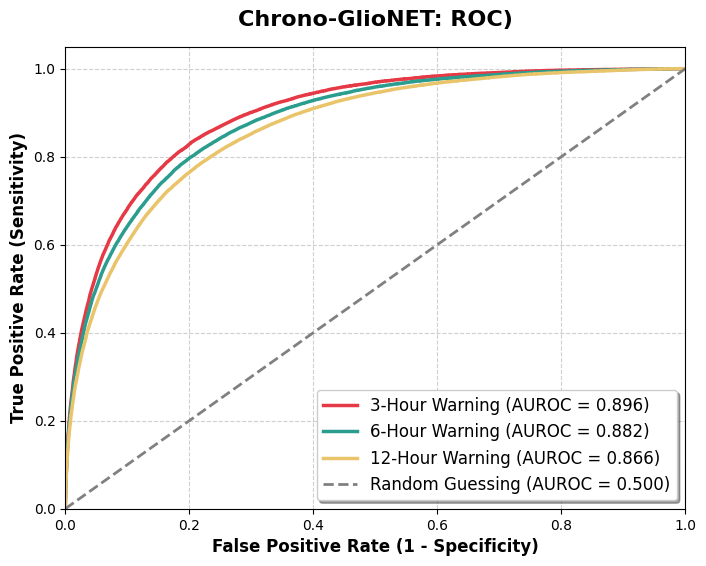

In [95]:

final_trained_model.eval()

all_targets = []
all_preds = []

with torch.no_grad():
    for batch_x, batch_y in val_loader:
        batch_x = batch_x.to(device)
        logits = final_trained_model(batch_x)
        
        preds = torch.sigmoid(logits) 
        
        all_targets.append(batch_y.numpy())
        all_preds.append(preds.cpu().numpy())

all_targets = np.vstack(all_targets)
all_preds = np.vstack(all_preds)

plt.figure(figsize=(8, 6))
colors = ['#E63946', '#2A9D8F', '#E9C46A'] 
horizons = ['3-Hour Warning', '6-Hour Warning', '12-Hour Warning']

for i in range(3):
    fpr, tpr, thresholds = roc_curve(all_targets[:, i], all_preds[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, color=colors[i], lw=2.5, 
             label=f'{horizons[i]} (AUROC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guessing (AUROC = 0.500)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='bold')
plt.title('Chrono-GlioNET: ROC)', fontsize=16, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=12, frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)



In [109]:

torch.save(final_trained_model.state_dict(), 'chrono_glionet_final_weights.pth')


In [116]:
dataiter = iter(val_loader)
real_x, real_y = next(dataiter)

torch.save({'x': real_x[:20], 'y': real_y[:20]}, 'real_val_samples.pt')

In [138]:

from IPython.display import display, HTML


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dataiter = iter(val_loader)
val_x, val_y = next(dataiter)

FEATURE_NAMES = [
    "Patient_ID", "ICULOS", "HospAdmTime", "Age", "Gender", 
    "HR", "MAP", "SBP", "DBP", "Resp", "Temp", "O2Sat", "Lactate", "Glucose"
]

def run_production_demo(patient_indices):
    dh = display(HTML("<p style='color: #8b949e;'>Initializing Chrono-GlioNET Live Feed...</p>"), display_id=True)
    time.sleep(1)
    
    for idx in patient_indices:
        patient_tensor = val_x[idx].unsqueeze(0).to(device)
        true_label = val_y[idx].numpy()
        
        with torch.no_grad():
            logits = final_trained_model(patient_tensor)
            probs = torch.sigmoid(logits).cpu().numpy()[0]
            
        vitals_to_show = [5, 6, 7, 8, 9, 10, 11, 12, 13] 
        headers_html = "<th style='padding: 10px; border-bottom: 2px solid #30363d; color: #58a6ff; text-align: left;'>Vital Sign</th>"
        headers_html += "".join([f"<th style='padding: 10px; border-bottom: 2px solid #30363d; color: #8b949e;'>Hr {i+1}</th>" for i in range(12)])
        
        rows_html = ""
        for feat_idx in vitals_to_show:
            v_name = FEATURE_NAMES[feat_idx]
            v_values = patient_tensor[0, :, feat_idx].cpu().numpy()
            cells = "".join([f"<td style='padding: 8px; color: #f0f6fc; border-bottom: 1px solid #21262d;'>{v:+.1f}</td>" for v in v_values])
            rows_html += f"<tr><td style='padding: 8px; color: #8b949e; font-weight: bold; text-align: left; border-bottom: 1px solid #21262d;'>{v_name}</td>{cells}</tr>"
        
        box_colors = ["#FF3333" if p > 0.65 else "#00CC66" for p in probs]
        
        status_text = "CRITICAL ALERT: IMMEDIATE INTERVENTION" if probs[0] > 0.65 else "SYSTEM STATUS: STABLE"
        status_color = "#FF3333" if probs[0] > 0.65 else "#00CC66"
        
        gt = [int(val) for val in true_label]
        
        dashboard_html = f"""
        <div style="background-color: #0d1117; color: #c9d1d9; padding: 30px; border-radius: 12px; font-family: 'Segoe UI', Tahoma, sans-serif; border: 2px solid #30363d; min-height: 600px;">
            
            <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 25px;">
                <div>
                    <h1 style="color: #58a6ff; margin: 0; font-size: 26px;">Chrono-GlioNET Monitor</h1>
                    <p style="color: #8b949e; margin: 5px 0 0 0; font-size: 14px;">Real-Time Inference Engine | Patient ID: #{idx}</p>
                </div>
                <div style="background-color: #161b22; padding: 12px; border-radius: 6px; border: 1px solid #30363d; text-align: center;">
                    <span style="color: #8b949e; font-size: 11px; font-weight: bold; display: block; margin-bottom: 4px;">GROUND TRUTH</span>
                    <span style="color: {'#FF3333' if gt[0]==1 else '#00CC66'}; font-weight: 1000;">3h({gt[0]})</span> | 
                    <span style="color: {'#FF3333' if gt[1]==1 else '#00CC66'}; font-weight: 1000;">6h({gt[1]})</span> | 
                    <span style="color: {'#FF3333' if gt[2]==1 else '#00CC66'}; font-weight: 1000;">12h({gt[2]})</span>
                </div>
            </div>
            
            <div style="background-color: #161b22; padding: 15px; border-radius: 8px; margin-bottom: 25px; border: 1px solid #30363d; overflow-x: auto;">
                <table style="width:100%; text-align:center; border-collapse: collapse; font-size: 13px;">
                    <thead><tr>{headers_html}</tr></thead>
                    <tbody>{rows_html}</tbody>
                </table>
            </div>
            
            <div style="display: flex; justify-content: space-between; gap: 15px; margin-bottom: 25px;">
                <div style="background-color: #161b22; padding: 20px; border-radius: 8px; flex: 1; border: 1px solid #30363d; border-top: 6px solid {box_colors[0]};">
                    <p style="margin: 0; color: #8b949e; font-size: 14px;">3h Risk Prob.</p>
                    <h2 style="margin: 8px 0 0 0; color: {box_colors[0]}; font-size: 36px;">{probs[0]*100:.1f}%</h2>
                </div>
                <div style="background-color: #161b22; padding: 20px; border-radius: 8px; flex: 1; border: 1px solid #30363d; border-top: 6px solid {box_colors[1]};">
                    <p style="margin: 0; color: #8b949e; font-size: 14px;">6h Risk Prob.</p>
                    <h2 style="margin: 8px 0 0 0; color: {box_colors[1]}; font-size: 36px;">{probs[1]*100:.1f}%</h2>
                </div>
                <div style="background-color: #161b22; padding: 20px; border-radius: 8px; flex: 1; border: 1px solid #30363d; border-top: 6px solid {box_colors[2]};">
                    <p style="margin: 0; color: #8b949e; font-size: 14px;">12h Risk Prob.</p>
                    <h2 style="margin: 8px 0 0 0; color: {box_colors[2]}; font-size: 36px;">{probs[2]*100:.1f}%</h2>
                </div>
            </div>
            
            <div style="background-color: {status_color}20; border: 2px solid {status_color}; padding: 18px; border-radius: 8px; text-align: center;">
                <h2 style="margin: 0; color: {status_color}; letter-spacing: 2px; font-weight: bold;">{status_text}</h2>
            </div>
        </div>
        """
        dh.update(HTML(dashboard_html))
        time.sleep(5)

run_production_demo([10, 15, 4, 30, 19])

Vital Sign,Hr 1,Hr 2,Hr 3,Hr 4,Hr 5,Hr 6,Hr 7,Hr 8,Hr 9,Hr 10,Hr 11,Hr 12
HR,+0.3,+0.4,-0.1,-0.3,+0.1,+0.3,+0.2,+0.3,-0.0,-0.3,-0.3,+0.6
MAP,+0.4,+0.3,+0.1,-0.2,+0.2,+0.4,+0.1,+0.2,+0.1,-0.2,-0.2,+0.8
SBP,+0.0,+0.0,+0.0,+0.0,+0.0,+0.0,+0.0,+0.0,+0.0,+0.0,+0.0,+0.0
DBP,-0.4,-0.4,-0.6,-0.2,-0.6,-0.8,-0.4,-0.6,-0.6,-0.6,-0.6,-0.4
Resp,+0.6,+0.6,+0.6,+0.6,-0.9,-0.9,-0.9,-0.9,+0.1,+0.1,+0.1,+0.3
Temp,-0.3,-0.3,+0.0,-0.3,-0.7,-0.3,-0.3,+0.0,+0.3,-0.3,-0.3,+0.0
O2Sat,+0.0,+0.0,+0.0,+0.0,+0.0,+0.0,+0.0,+0.0,+0.0,+0.0,+0.0,+0.0
Lactate,+0.5,+0.5,+0.5,+0.5,-0.3,-0.3,-0.3,-0.3,-0.3,-0.3,-0.3,-0.3
Glucose,+1.0,+1.0,+1.0,+1.0,+1.0,+1.0,+1.0,+1.0,+1.0,+1.0,+0.0,+1.0
